In [1]:
# Define function
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertModel

In [2]:
# Load data
file_path = '1-url_BERT_features.csv'
df = pd.read_csv(file_path)

# Pick one video
video_url = df['url'].iloc[0]
video_label = df[df['url'] == video_url]['label'].iloc[0]
title = df[df['url'] == video_url]['title'].tolist()

In [3]:
# Load BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

Text embedding

In [4]:
def avg_embedding(texts):
    vecs = []
    for t in texts:
        if t in ["NO_COMMENTS","COMMENTS_DISABLED"]: continue
        enc = tokenizer(t, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
        with torch.no_grad():
          vec = model(**enc).last_hidden_state[:,0,:].squeeze().numpy()
          vecs.append(vec)
    return np.mean(vecs, axis=0) if vecs else None

In [5]:
# Average per video

total_links = df['url'].nunique()
print(f"Total Links: {total_links}")


results = []
for url in df['url'].unique():
    label = df[df['url']==url]['label'].iloc[0]
    title = df[df['url']==url]['title'].tolist()
    avg_vec = avg_embedding(title)
    if avg_vec is not None:
        results.append([url,title, label] + avg_vec.tolist())
        print(f"Processed {len(results)}/{total_links}: {url}")

Total Links: 661
Processed 1/661: https://youtube.com/shorts/aa4rZp_vfS4?si=2t9E8NsgmwoDO1QB
Processed 2/661: https://youtube.com/shorts/LBK1qGei-Sg?si=RiETYWMLn66TG-Lu
Processed 3/661: https://youtube.com/shorts/Q304WXr0fDU?si=AYIeFMt6KlotqIDK
Processed 4/661: https://youtube.com/shorts/s6NJ-0lfRD8?si=qPbLnlA8NkpHLxsq
Processed 5/661: https://youtube.com/shorts/YJQPjPWU0dM?si=BhqGtkKaSzux5hCY
Processed 6/661: https://youtube.com/shorts/2yAOdi3n6f8?si=BgjtJXsbDLkM4D_h
Processed 7/661: https://youtube.com/shorts/3EfqdF7lcNM?si=4Bb4ow13IQx1kJoL
Processed 8/661: https://youtube.com/shorts/6k0oqfs5Iow?si=0B9lizlpj35L3XFQ
Processed 9/661: https://youtube.com/shorts/fy1JKuwDL4M?si=q1VW2a1645qeq-PE
Processed 10/661: https://youtube.com/shorts/IVufSf9H-_0?si=TBm0l_jpGTJS2pRN
Processed 11/661: https://youtube.com/shorts/JDlpBbB5OVk?si=OnRS-pKvWpRBs6xx
Processed 12/661: https://youtube.com/shorts/KGzXEGH_BkI?si=kE5FVjKWMBiBujII
Processed 13/661: https://youtube.com/shorts/mDbeKgd-27o?si=Ok3-DthY

In [11]:
print(len( avg_vec)) 

768


In [13]:
print(len( results)) 

661


In [14]:
print(len(results[0]))

771


In [8]:
# Number of embedding features
num_features = len(results[0]) - 3


# Create column names
columns = ['url', "title",'label'] + [f'title_{i}' for i in range(num_features)]


# Convert list to DataFrame
df_output = pd.DataFrame(results, columns=columns)


In [9]:
# Save to CSV
output_path = '1.1-url_title_features.csv'
df_output.to_csv(output_path, index=False)

print(f"CSV saved successfully: {output_path}")
print(f"Total videos : {len(df_output)}")
print(f"Total columns: {len(df_output.columns)}")

CSV saved successfully: F:/Bits Sem4/1-BITS_MTech_AIML_Final_Project/1.1-url_title_features.csv
Total videos : 661
Total columns: 771


In [15]:
print(df_output.head())


                                                 url  \
0  https://youtube.com/shorts/aa4rZp_vfS4?si=2t9E...   
1  https://youtube.com/shorts/LBK1qGei-Sg?si=RiET...   
2  https://youtube.com/shorts/Q304WXr0fDU?si=AYIe...   
3  https://youtube.com/shorts/s6NJ-0lfRD8?si=qPbL...   
4  https://youtube.com/shorts/YJQPjPWU0dM?si=BhqG...   

                                               title     label   title_0  \
0  [ducking save seriously injured cat #duckrescu...  Explicit -0.433471   
1  [🫣😄​أقوى المقاطع المضحكة للحمير – لن تتوقف عن ...  Explicit -0.322783   
2             [#momcozy#momlife#baby AA 501 #mother]  Explicit -0.397050   
3  [🐐🤭#viralshots #youtubeshorts #goat #beautiful...  Explicit  0.245136   
4                                        [01-Jul-26]  Explicit -1.010023   

    title_1   title_2   title_3   title_4   title_5   title_6  ...  title_758  \
0 -0.094420 -0.042714 -0.085980 -0.236279 -0.001080  0.406059  ...  -0.312115   
1  0.016058 -0.439717 -0.597225 -0.381793 -0

In [16]:
print(df_output.iloc[9])

url          https://youtube.com/shorts/IVufSf9H-_0?si=TBm0...
title        [Unlock the Power of Smart Learning withAdvanc...
label                                                 Explicit
title_0                                              -0.109424
title_1                                               0.248434
                                   ...                        
title_763                                            -0.134471
title_764                                            -0.084551
title_765                                            -0.244306
title_766                                             0.303077
title_767                                             0.448468
Name: 9, Length: 771, dtype: object


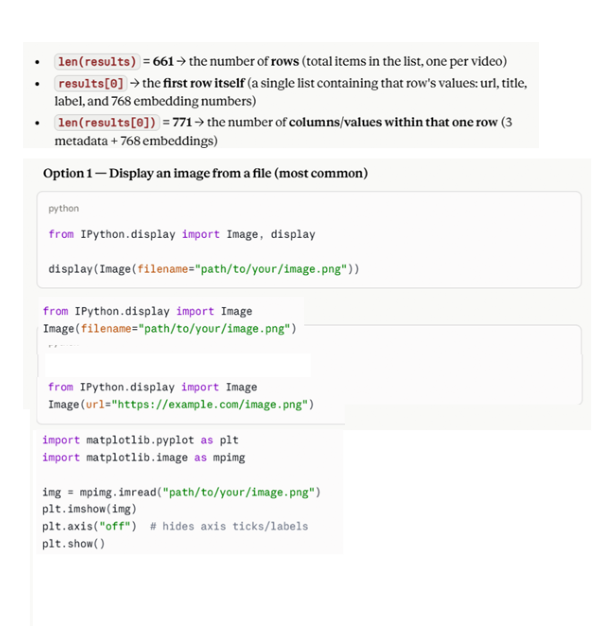

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("Remarks-1.png")

plt.figure(figsize=(10, 8))   # width, height in inches — increase these numbers
plt.imshow(img)
plt.axis("off")
plt.show()